In [1]:
import os
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers, Input, Model
from keras import backend as K
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


2025-07-25 12:47:23.524389: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-25 12:47:23.535279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753426043.547699  975511 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753426043.551417  975511 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753426043.561668  975511 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def load_lfw_and_split(image_dir, target_shape, test_split_size=0.2, random_state=42):
    all_images = []
    print(f"Loading images from '{image_dir}'...")
    
    for dirpath, _, filenames in os.walk(image_dir):
        for filename in filenames:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(dirpath, filename)
                try:
                    img = Image.open(file_path).convert("RGB").resize(target_shape)
                    all_images.append(np.array(img, dtype="float32"))
                except Exception as e:
                    print(f"Warning: Failed to load image {file_path}. Error: {e}")

    X = np.array(all_images)
    
    # --- FIX 1: NORMALIZE THE DATA ---
    # Divide all pixel values by 255 to scale them to the [0, 1] range.
    X = X / 255.0
    
    print(f"\nSuccessfully loaded and normalized {len(X)} images.")
    print(f"Shape of the full dataset: {X.shape}")

    print(f"Splitting data into training ({1-test_split_size:.0%}) and testing ({test_split_size:.0%}) sets...")
    trainX, testX = train_test_split(X, test_size=test_split_size, random_state=random_state)
    
    return trainX, testX

# --- Re-run the data loading with the fix ---
IMAGE_DIR = 'LFW' 
TARGET_SHAPE = (128, 128)
TEST_SPLIT = 0.2

trainX, testX = load_lfw_and_split(
    image_dir=IMAGE_DIR,
    target_shape=TARGET_SHAPE,
    test_split_size=TEST_SPLIT
)

print("\n--- Splitting Complete ---")
print(f"Shape of training data (trainX): {trainX.shape}")
print(f"Shape of testing data (testX):   {testX.shape}")
print("--------------------------")

Loading images from 'LFW'...



Successfully loaded and normalized 13233 images.
Shape of the full dataset: (13233, 128, 128, 3)
Splitting data into training (80%) and testing (20%) sets...

--- Splitting Complete ---
Shape of training data (trainX): (10586, 128, 128, 3)
Shape of testing data (testX):   (2647, 128, 128, 3)
--------------------------


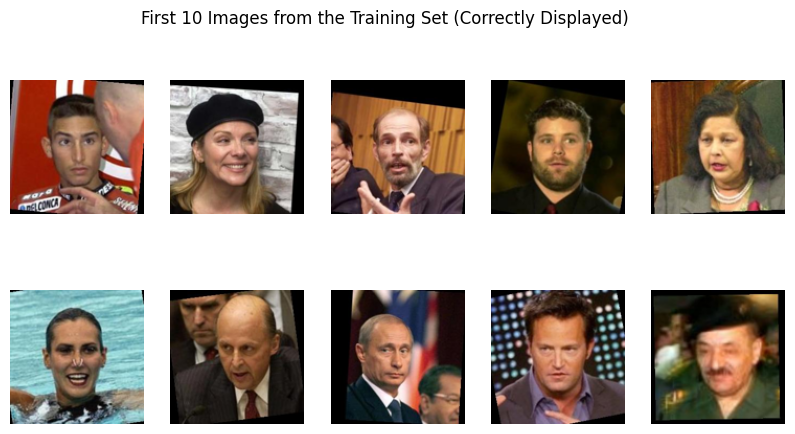

In [3]:
plt.figure(figsize=(10, 5))
plt.suptitle("First 10 Images from the Training Set (Correctly Displayed)")

for i in range(10):
    plt.subplot(2, 5, i + 1)
    # FIX: Rescale from [0, 1] back to [0, 255] before converting to uint8
    image = (trainX[i] * 255).astype('uint8')
    plt.imshow(image)
    plt.axis('off')

plt.show()

** Building the VAE Model Components **

In [4]:
LATENT_DIM = 2
IMAGE_SHAPE = (trainX.shape[1], trainX.shape[2], trainX.shape[3])

# --- Encoder Architecture ---
encoder_inputs = Input(shape=IMAGE_SHAPE)
x_enc = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x_enc = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x_enc)

# --- FIX: Use the .shape attribute instead of K.int_shape ---
shape_before_flattening = x_enc.shape

x_enc = layers.Flatten()(x_enc)
x_enc = layers.Dense(16, activation='relu')(x_enc)

z_mean = layers.Dense(LATENT_DIM, name='z_mean')(x_enc)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x_enc)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(LATENT_DIM,), name='z')([z_mean, z_log_var])

# Instantiate the encoder model
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')


# --- Decoder Architecture (Corrected to Upsample) ---
decoder_inputs = Input(shape=(LATENT_DIM,))
# Upscale to match the shape before the encoder's flatten layer
# Note: shape_before_flattening[1:] excludes the batch size dimension
x_dec = layers.Dense(np.prod(shape_before_flattening[1:]), activation="relu")(decoder_inputs)
x_dec = layers.Reshape(shape_before_flattening[1:])(x_dec)
# Now upsample from 32x32 back to 128x128
x_dec = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x_dec)
x_dec = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x_dec)
# Final layer to get back to 3 channels, with sigmoid for [0, 1] output
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x_dec)

# Instantiate the decoder model
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

print("\nEncoder and Decoder architectures have been corrected and are ready.")

I0000 00:00:1753426056.796277  975511 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5070 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9



Encoder and Decoder architectures have been corrected and are ready.


**Defining a Flexible VAE Model**

In [5]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, loss_type='bce', **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]
        
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def _calculate_loss(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        
        if self.loss_type == 'bce':
            # BinaryCrossentropy can be called as a class too, this is the modern way
            bce_loss_fn = keras.losses.BinaryCrossentropy(reduction="none")
            reconstruction_loss_tensor = bce_loss_fn(data, reconstruction)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(reconstruction_loss_tensor, axis=(1, 2)))
            
        elif self.loss_type == 'mse':
            # --- FIX: Use the class-based MeanSquaredError ---
            # Instantiate the class, then call it on the data
            mse_loss_fn = keras.losses.MeanSquaredError(reduction="none")
            reconstruction_loss_tensor = mse_loss_fn(data, reconstruction)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(reconstruction_loss_tensor, axis=(1, 2)))
        else:
            raise ValueError(f"Unknown loss_type: {self.loss_type}")

        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        
        total_loss = reconstruction_loss + kl_loss
        
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
            
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._calculate_loss(data)
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self._calculate_loss(data)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

print("VAE model class updated with correct loss function calls.")

VAE model class updated with correct loss function calls.


**Train the VAE with Binary Cross-Entropy (BCE) Loss**

In [6]:
print("\n--- Training VAE with BCE Loss ---")

# Create fresh instances of the encoder and decoder for this model
encoder_bce = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder_bce')
decoder_bce = Model(decoder_inputs, decoder_outputs, name='decoder_bce')
vae_bce = VAE(encoder_bce, decoder_bce, loss_type='bce')

vae_bce.compile(optimizer=keras.optimizers.Adam())
history_bce = vae_bce.fit(trainX, epochs=15, batch_size=16, validation_data=(testX, None), verbose=1)


--- Training VAE with BCE Loss ---
Epoch 1/15


I0000 00:00:1753426060.579161  975932 service.cc:152] XLA service 0x67d8ac30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753426060.579186  975932 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-07-25 12:47:40.628262: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753426060.832171  975932 cuda_dnn.cc:529] Loaded cuDNN version 90501


 37/662 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.7038 - reconstruction_loss: 11126.2686 - total_loss: 11132.9717

I0000 00:00:1753426067.445393  975932 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


662/662 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - kl_loss: 14.7379 - reconstruction_loss: 10220.8750 - total_loss: 10235.6104 - val_kl_loss: 14.5520 - val_reconstruction_loss: 9868.7109 - val_total_loss: 9883.2656
Epoch 2/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 14.1859 - reconstruction_loss: 9861.5176 - total_loss: 9875.7031 - val_kl_loss: 11.8764 - val_reconstruction_loss: 9851.3770 - val_total_loss: 9863.2549
Epoch 3/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 11.0164 - reconstruction_loss: 9812.7881 - total_loss: 9823.8037 - val_kl_loss: 9.5905 - val_reconstruction_loss: 9834.6240 - val_total_loss: 9844.2119
Epoch 4/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 9.3023 - reconstruction_loss: 9828.1035 - total_loss: 9837.4082 - val_kl_loss: 8.7048 - val_reconstruction_loss: 9831.8955 - val_total_loss: 9840.5996
Epoch 5/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 8.6494 - reconstruction_loss: 9801.7314 - total_loss: 9810.3789 - val_kl_loss: 11.0

**Train the VAE with Mean Squared Error (MSE) Loss**

In [7]:
print("\n--- Training VAE with MSE Loss ---")

# It's crucial to create new models to train from scratch for a fair comparison
encoder_mse = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder_mse')
decoder_mse = Model(decoder_inputs, decoder_outputs, name='decoder_mse')
vae_mse = VAE(encoder_mse, decoder_mse, loss_type='mse')

vae_mse.compile(optimizer=keras.optimizers.Adam())
history_mse = vae_mse.fit(trainX, epochs=15, batch_size=16, validation_data=(testX, None), verbose=1)


--- Training VAE with MSE Loss ---


Epoch 1/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - kl_loss: 8.1644 - reconstruction_loss: 806.5748 - total_loss: 814.7393 - val_kl_loss: 7.3045 - val_reconstruction_loss: 819.9639 - val_total_loss: 827.2682
Epoch 2/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 7.5174 - reconstruction_loss: 805.3753 - total_loss: 812.8928 - val_kl_loss: 7.6560 - val_reconstruction_loss: 826.0012 - val_total_loss: 833.6571
Epoch 3/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 7.4394 - reconstruction_loss: 802.1819 - total_loss: 809.6215 - val_kl_loss: 7.2781 - val_reconstruction_loss: 820.2904 - val_total_loss: 827.5684
Epoch 4/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 7.3651 - reconstruction_loss: 803.2184 - total_loss: 810.5836 - val_kl_loss: 7.4980 - val_reconstruction_loss: 820.7797 - val_total_loss: 828.2778
Epoch 5/15
662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 7.2640 - reconstruction_loss: 800.3651 - total_loss: 807.6290 - val_kl_loss: 7.3893 - val_reconst

In [8]:
# Select sample images for reconstruction visualization
n = 10
sample_images = testX[:n]

# Generate reconstructions from both models
reconstructed_bce = vae_bce.predict(sample_images)
reconstructed_mse = vae_mse.predict(sample_images)

# Generate latent space representations for the entire test set
z_mean_bce, _, _ = vae_bce.encoder.predict(testX, batch_size=16)
z_mean_mse, _, _ = vae_mse.encoder.predict(testX, batch_size=16)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


**

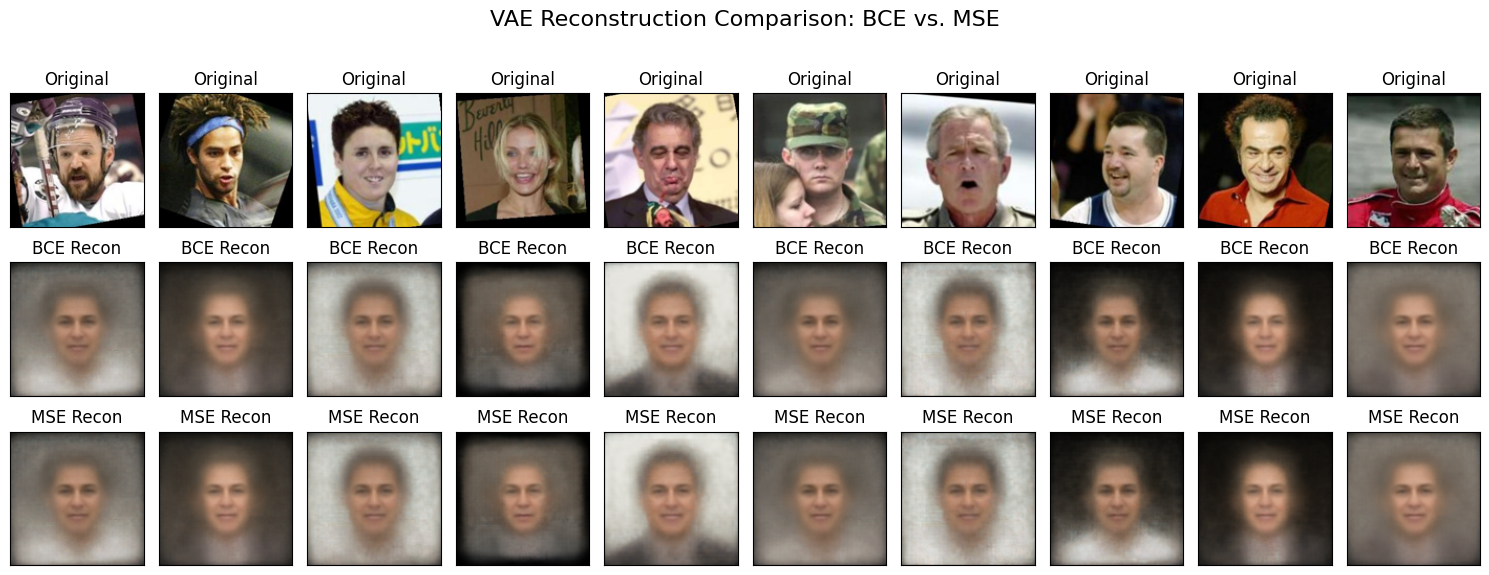

In [9]:
plt.figure(figsize=(15, 6))
plt.suptitle("VAE Reconstruction Comparison: BCE vs. MSE", fontsize=16)

for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(sample_images[i].reshape(128, 128, 3), cmap='gray')
    ax.set_title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # BCE Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed_bce[i].reshape(128, 128, 3), cmap='gray')
    ax.set_title("BCE Recon")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # MSE Reconstructed Image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed_mse[i].reshape(128, 128, 3), cmap='gray')
    ax.set_title("MSE Recon")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

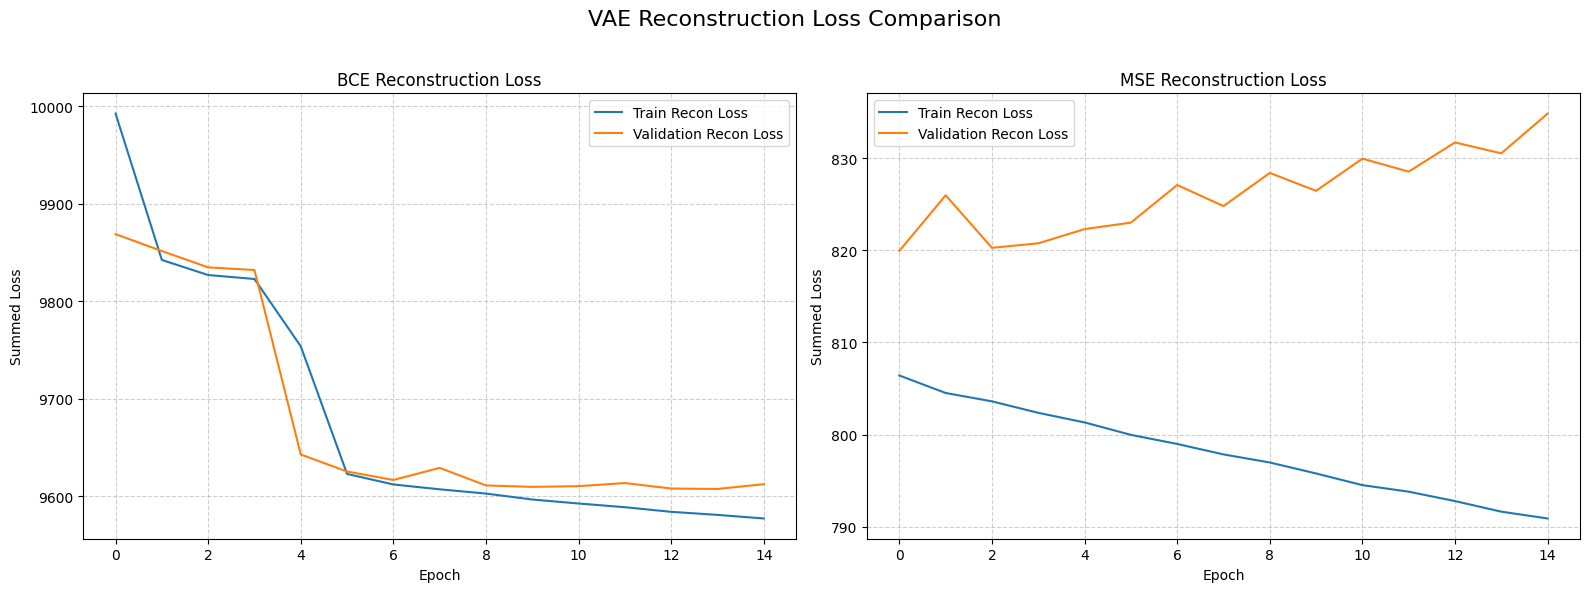

: 

In [ ]:
# --- Create the figure and axes for the plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VAE Reconstruction Loss Comparison', fontsize=16)

# --- Plot 1: BCE Loss Curve ---
# Check if the history object exists and has the required keys
if 'history_bce' in locals() and history_bce is not None:
    ax1.plot(history_bce.history['reconstruction_loss'], label='Train Recon Loss')
    ax1.plot(history_bce.history['val_reconstruction_loss'], label='Validation Recon Loss')
    ax1.set_title('BCE Reconstruction Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Summed Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
else:
    ax1.set_title('BCE History not available')

# --- Plot 2: MSE Loss Curve ---
# Check if the history object exists and has the required keys
if 'history_mse' in locals() and history_mse is not None:
    ax2.plot(history_mse.history['reconstruction_loss'], label='Train Recon Loss')
    ax2.plot(history_mse.history['val_reconstruction_loss'], label='Validation Recon Loss')
    ax2.set_title('MSE Reconstruction Loss')
    ax2.set_xlabel('Epoch')
    # The y-axis label can be shared or set individually
    ax2.set_ylabel('Summed Loss') 
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
else:
    ax2.set_title('MSE History not available')

# --- Display the plots ---
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()